### 02 - Surrogate Model Demo

Fit a predictive surrogate model to each function and use it to propose Week 5 queries.

This notebook covers:
1. Why surrogate models now?
2. Data summary
3. How the model works
4. Which input dimensions actually matter
5. Model predictions for the 2D functions
6. Where to query next (and why)
7. Baseline data we overlooked
8. Week 5 proposals
9. Takeaway

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.surrogate import load_all_data, fit_gp, optimize_acquisition, _ucb, _ei
from src.functions_map import FUNCTION_DIMENSIONS

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

PROJECT_ROOT = Path('..').resolve()
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/sethu/work/ml-learning/Capstone-related/bayesian-bbo-capstone


### 1. Why Surrogate Models Now?

Over the first four weeks we collected 14–44 data points per function (baseline samples plus weekly queries). That's enough to train a predictive model that estimates outputs across the *entire* input space — not just at the points we've already queried.

Instead of relying on intuition to choose where to query next, we can now let the model recommend the most promising point for each function.

### 2. Data Summary

How much data does each function have?

In [2]:
# Count data points per function (baseline + 4 weekly queries)
summary_rows = []
for fid in range(1, 9):
    X, y = load_all_data(fid)
    dim = FUNCTION_DIMENSIONS[fid]
    baseline_path = PROJECT_ROOT / 'data' / 'baseline' / f'function_{fid}_baseline.csv'
    n_baseline = len(pd.read_csv(baseline_path))
    n_weekly = len(y) - n_baseline
    summary_rows.append({
        'Function': fid,
        'Dimensions': dim,
        'Baseline': n_baseline,
        'Weekly': n_weekly,
        'Total': len(y),
        'Best y': y.max()
    })

summary_df = pd.DataFrame(summary_rows)
print('Data Point Summary')
print('=' * 65)
print(summary_df.to_string(index=False))

Data Point Summary
 Function  Dimensions  Baseline  Weekly  Total        Best y
        1           2        10       5     15  1.567310e-15
        2           2        10       5     15  6.112052e-01
        3           3        15       5     20 -3.483531e-02
        4           4        30       5     35  6.958826e-01
        5           4        20       5     25  3.338753e+03
        6           5        20       5     25 -7.142650e-01
        7           6        30       5     35  1.364968e+00
        8           8        40       5     45  9.729255e+00


### 3. How the Model Works

We fit a model that learns a smooth surface through our observed data:

- Where data is dense, the model is confident in its predictions.
- Where data is sparse, the model is uncertain.

We use this uncertainty to decide where to query next — the model scores candidate points by balancing predicted output against uncertainty, favouring points where we might learn something valuable.

The model also learns an importance score for each input dimension:
- High importance = the function changes rapidly along that axis
- Low importance = that dimension barely affects the output

In [3]:
# Fit surrogate models for all 8 functions
gp_models = {}
all_data = {}

for fid in range(1, 9):
    gp, X, y = fit_gp(fid)
    gp_models[fid] = gp
    all_data[fid] = (X, y)
    print(f'Function {fid}: fitted model  (data shape: {X.shape})')

print('\nAll models fitted successfully.')

Function 1: fitted model  (data shape: (15, 2))


Function 2: fitted model  (data shape: (15, 2))


Function 3: fitted model  (data shape: (20, 3))


Function 4: fitted model  (data shape: (35, 4))


Function 5: fitted model  (data shape: (25, 4))


Function 6: fitted model  (data shape: (25, 5))


Function 7: fitted model  (data shape: (35, 6))


Function 8: fitted model  (data shape: (45, 8))

All models fitted successfully.


### 4. Which Dimensions Matter?

The model learns how much each input dimension influences the output. A low importance score means the function barely changes along that axis. A high importance score means it changes rapidly.

This is valuable because it can reveal which inputs we should focus on — and which ones we can essentially ignore.

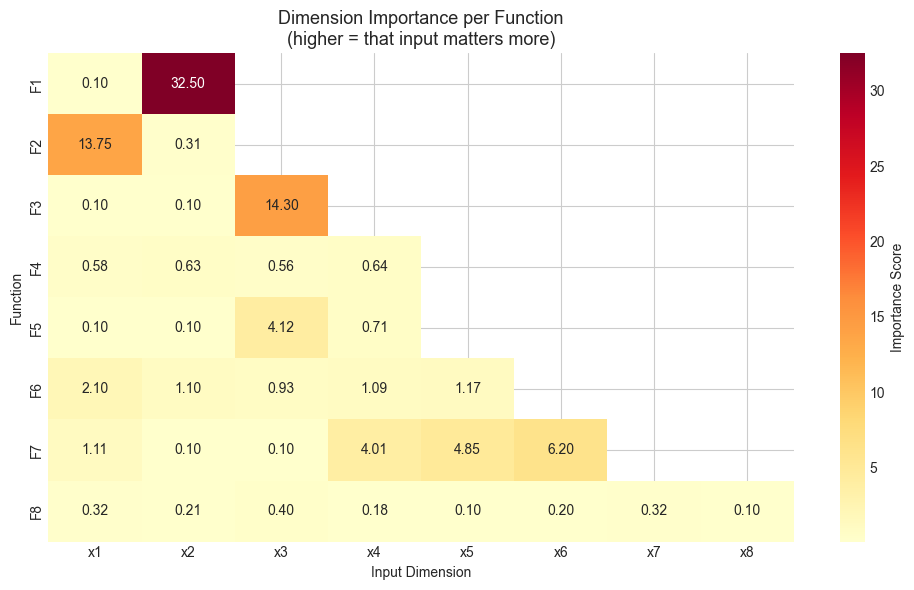

In [4]:
# Extract dimension importance (inverse of learned length scales)
importance_data = {}

for fid in range(1, 9):
    gp = gp_models[fid]
    # The Matern kernel is the second part of the product kernel (k0 * k1 + k2)
    # Access length_scale from the fitted kernel
    kernel = gp.kernel_
    # Product kernel: k0 * k1, the Matern is k1
    matern = kernel.k1.k2  # ConstantKernel * Matern + WhiteKernel -> k1 = (Const * Matern), k1.k2 = Matern
    length_scales = matern.length_scale
    if np.isscalar(length_scales):
        length_scales = np.array([length_scales])
    # Importance = 1 / length_scale (shorter length scale = more important)
    importance = 1.0 / length_scales
    importance_data[fid] = importance

# Build a padded matrix for the heatmap (max 8 dimensions)
max_dim = 8
imp_matrix = np.full((8, max_dim), np.nan)
for fid in range(1, 9):
    imp = importance_data[fid]
    imp_matrix[fid - 1, :len(imp)] = imp

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 6))
mask = np.isnan(imp_matrix)
sns.heatmap(imp_matrix, annot=True, fmt='.2f', mask=mask,
            xticklabels=[f'x{i}' for i in range(1, max_dim + 1)],
            yticklabels=[f'F{i}' for i in range(1, 9)],
            cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Importance Score'})
ax.set_title('Dimension Importance per Function\n(higher = that input matters more)', fontsize=13)
ax.set_xlabel('Input Dimension')
ax.set_ylabel('Function')
plt.tight_layout()
plt.show()

### Reading the importance heatmap

The heatmap above shows which dimensions seem important or unimportant *with the data collected so far*. As we add more weekly results, these scores will shift — a dimension that looks unimportant early on might turn out to matter once the model has more data to learn from.

Low-scoring dimensions are ones the model thinks barely affect the output. High-scoring ones are where the output changes rapidly — those are the axes worth focusing future queries on.

### 5. Model Predictions (2D Functions)

For Functions 1 and 2 (both 2D) we can visualise the full predicted surface. The contour plots below show:
- Predicted output (left) — the model's best guess at every point
- Prediction confidence (right) — where the model is certain vs uncertain
- Black dots — observed data points
- Red star — the model's proposed next query

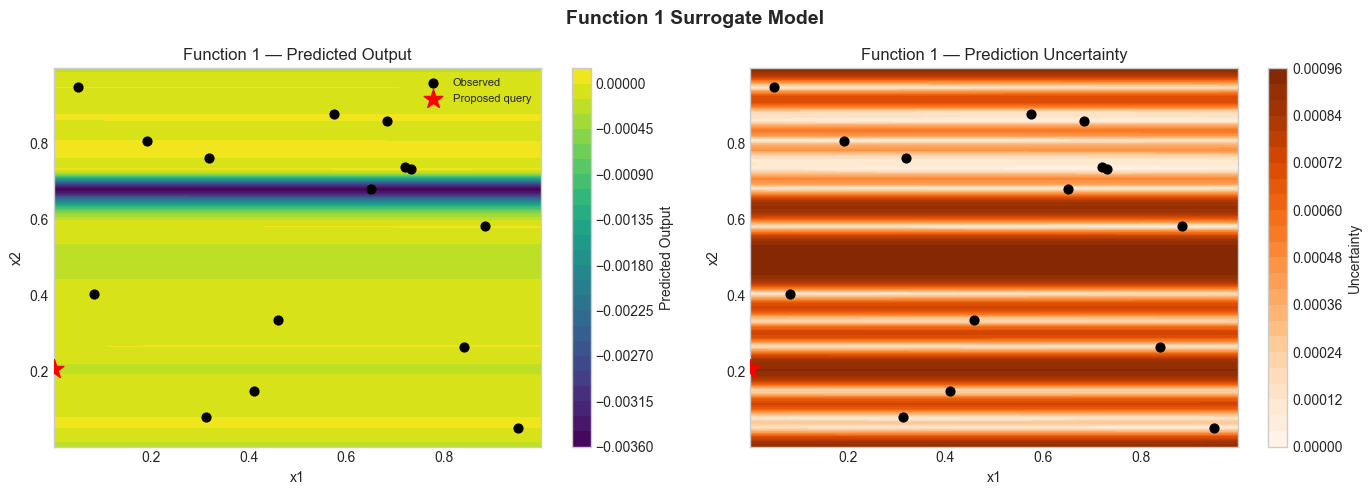

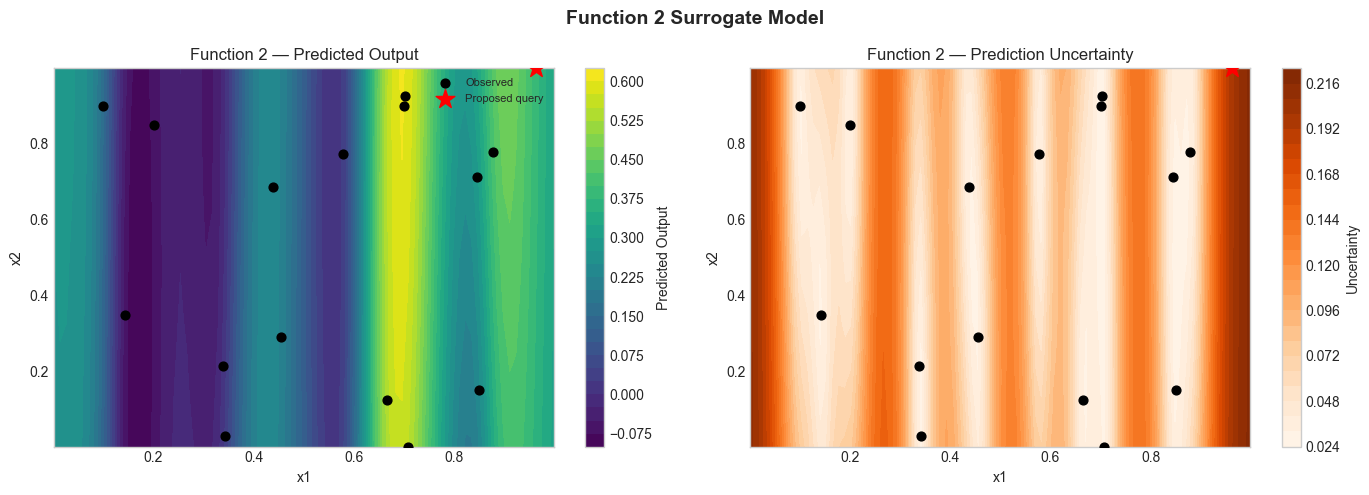

In [5]:
# Prediction surfaces for 2D functions (F1 and F2)
grid_res = 80
x1_grid = np.linspace(0.001, 0.999, grid_res)
x2_grid = np.linspace(0.001, 0.999, grid_res)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1.ravel(), X2.ravel()])

for fid in [1, 2]:
    gp = gp_models[fid]
    X_obs, y_obs = all_data[fid]
    x_star = optimize_acquisition(fid, gp=gp, X=X_obs, y=y_obs)

    mu, sigma = gp.predict(X_grid, return_std=True)
    MU = mu.reshape(grid_res, grid_res)
    SIGMA = sigma.reshape(grid_res, grid_res)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Predicted output
    ax = axes[0]
    cf = ax.contourf(X1, X2, MU, levels=30, cmap='viridis')
    plt.colorbar(cf, ax=ax, label='Predicted Output')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c='black', s=40, zorder=5, label='Observed')
    ax.scatter(x_star[0], x_star[1], marker='*', c='red', s=200, zorder=6, label='Proposed query')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'Function {fid} — Predicted Output')
    ax.legend(loc='upper right', fontsize=8)

    # Confidence (uncertainty)
    ax = axes[1]
    cf = ax.contourf(X1, X2, SIGMA, levels=30, cmap='Oranges')
    plt.colorbar(cf, ax=ax, label='Uncertainty')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c='black', s=40, zorder=5)
    ax.scatter(x_star[0], x_star[1], marker='*', c='red', s=200, zorder=6)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'Function {fid} — Prediction Uncertainty')

    plt.suptitle(f'Function {fid} Surrogate Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6. Where to Query Next

The scoring rule picks the point with the best combination of high predicted output and high uncertainty — it favours points where we might learn something valuable.

Below we visualise the scoring surface for the 2D functions. The brighter the region, the more the model wants to query there.

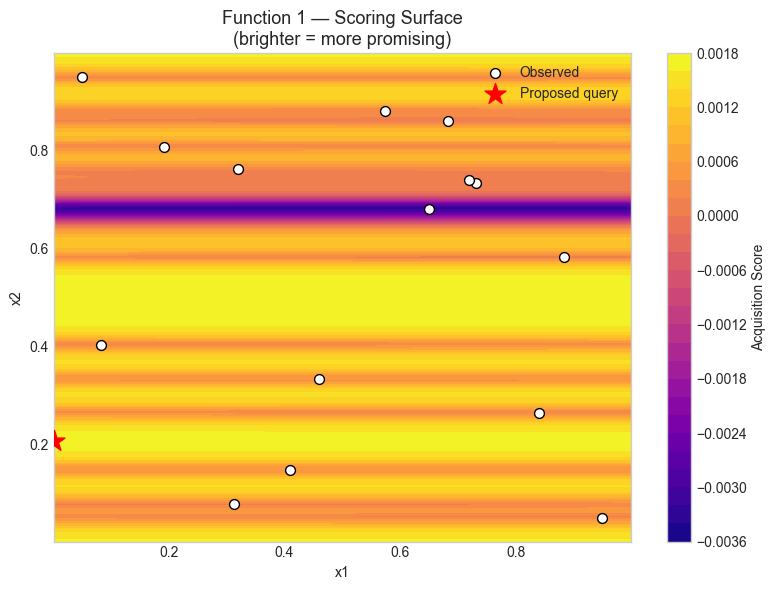

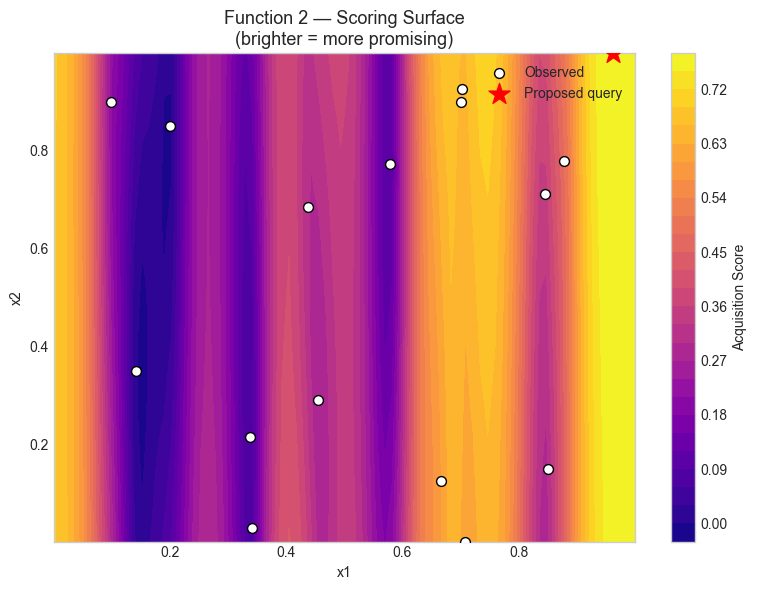

In [6]:
# Acquisition surface for 2D functions
for fid in [1, 2]:
    gp = gp_models[fid]
    X_obs, y_obs = all_data[fid]
    y_best = y_obs.max()
    x_star = optimize_acquisition(fid, gp=gp, X=X_obs, y=y_obs)

    acq_vals = _ucb(gp, X_grid)
    ACQ = acq_vals.reshape(grid_res, grid_res)

    fig, ax = plt.subplots(figsize=(8, 6))
    cf = ax.contourf(X1, X2, ACQ, levels=30, cmap='plasma')
    plt.colorbar(cf, ax=ax, label='Acquisition Score')
    ax.scatter(X_obs[:, 0], X_obs[:, 1], c='white', edgecolors='black', s=50, zorder=5, label='Observed')
    ax.scatter(x_star[0], x_star[1], marker='*', c='red', s=250, zorder=6, label='Proposed query')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_title(f'Function {fid} — Scoring Surface\n(brighter = more promising)', fontsize=13)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

### 7. Baseline Data We Overlooked

An important finding: for several functions, some baseline points (the initial samples we were given) actually had *better* results than any of our weekly queries.

The surrogate model uses all available data — baseline and weekly — so it automatically learns from these high-performing baseline points that we hadn't fully exploited.

In [7]:
def get_y(row):
    """Handle CSV quirk where y lands in wrong column for lower-dim functions."""
    if pd.notna(row['y']):
        return row['y']
    return float(row.dropna().iloc[-1])

# Compare baseline best vs weekly best for each function
comparison_rows = []
for fid in range(1, 9):
    bl = pd.read_csv(PROJECT_ROOT / 'data' / 'baseline' / f'function_{fid}_baseline.csv')
    bl_best = bl['y'].max()

    # Collect weekly results for this function
    weekly_ys = []
    for week in range(1, 5):
        wk = pd.read_csv(PROJECT_ROOT / 'data' / 'weekly' / f'week_{week:02d}.csv')
        row = wk[wk['function_id'] == fid]
        if not row.empty:
            weekly_ys.append(get_y(row.iloc[0]))
    wk_best = max(weekly_ys) if weekly_ys else None

    baseline_wins = bl_best > wk_best if wk_best is not None else False
    comparison_rows.append({
        'Function': fid,
        'Baseline Best': bl_best,
        'Weekly Best': wk_best,
        'Overall Best': max(bl_best, wk_best) if wk_best is not None else bl_best,
        'Baseline Wins?': 'YES' if baseline_wins else ''
    })

comp_df = pd.DataFrame(comparison_rows)
print('Baseline vs Weekly Best Results')
print('=' * 75)
print(comp_df.to_string(index=False))
print()
print('Functions where baseline data outperforms all weekly queries:',
      [r['Function'] for r in comparison_rows if r['Baseline Wins?'] == 'YES'])

Baseline vs Weekly Best Results
 Function  Baseline Best   Weekly Best  Overall Best Baseline Wins?
        1   7.710875e-16  1.567310e-15  1.567310e-15               
        2   6.112052e-01  5.925367e-01  6.112052e-01            YES
        3  -3.483531e-02 -8.842081e-02 -3.483531e-02            YES
        4  -4.025542e+00 -4.513041e+00 -4.025542e+00            YES
        5   1.088860e+03  3.338753e+03  3.338753e+03               
        6  -7.142650e-01 -1.390272e+00 -7.142650e-01            YES
        7   1.364968e+00  3.773384e-01  1.364968e+00            YES
        8   9.598482e+00  9.687050e+00  9.687050e+00               

Functions where baseline data outperforms all weekly queries: [2, 3, 4, 6, 7]


### 8. Week 5 Proposals

Using the surrogate model, here are the recommended query points for Week 5:

In [8]:
# Generate Week 5 proposals from the fitted models
print('Week 5 — Model-Driven Query Proposals')
print('=' * 60)

proposals = {}
for fid in range(1, 9):
    gp = gp_models[fid]
    X_obs, y_obs = all_data[fid]
    x_star = optimize_acquisition(fid, gp=gp, X=X_obs, y=y_obs)
    proposals[fid] = x_star
    formatted = ', '.join(f'{v:.6f}' for v in x_star)
    print(f'Function {fid}: [{formatted}]')

print()
print('These proposals are saved in queries/week_05.txt')

Week 5 — Model-Driven Query Proposals
Function 1: [0.001001, 0.206113]
Function 2: [0.962423, 0.999000]


Function 3: [0.001000, 0.001000, 0.651483]


Function 4: [0.423264, 0.417563, 0.269631, 0.435621]


Function 5: [0.999000, 0.999000, 0.999000, 0.999000]


Function 6: [0.508342, 0.395530, 0.684253, 0.751634, 0.001000]


Function 7: [0.001000, 0.217007, 0.933881, 0.278473, 0.366733, 0.703509]


Function 8: [0.001000, 0.001000, 0.001000, 0.001000, 0.999000, 0.001000, 0.001000, 0.999000]

These proposals are saved in queries/week_05.txt


In [9]:
# Summary table: what the model predicts at each proposed point
pred_rows = []
for fid in range(1, 9):
    gp = gp_models[fid]
    x_star = proposals[fid].reshape(1, -1)
    mu, sigma = gp.predict(x_star, return_std=True)
    X_obs, y_obs = all_data[fid]
    pred_rows.append({
        'Function': fid,
        'Current Best': y_obs.max(),
        'Predicted Output': mu[0],
        'Uncertainty': sigma[0],
    })

pred_df = pd.DataFrame(pred_rows)
print('Model Predictions at Proposed Points')
print('=' * 65)
print(pred_df.to_string(index=False))

Model Predictions at Proposed Points
 Function  Current Best  Predicted Output  Uncertainty
        1  1.567310e-15         -0.000168     0.000922
        2  6.112052e-01          0.386098     0.196724
        3 -3.483531e-02         -0.093306     0.088850
        4  6.958826e-01          0.386692     0.352601
        5  3.338753e+03       3410.146881   253.880166
        6 -7.142650e-01         -0.523817     0.200723
        7  1.364968e+00          1.304313     0.120930
        8  9.729255e+00          9.940838     0.279037


### 9. Takeaway

Weeks 1–4 built intuition about each function through manual exploration and simple heuristics.

Week 5 hands the steering wheel to the model. With enough accumulated data, the surrogate model can now:
- Predict outputs across the full input space
- Quantify where it's confident and where it's uncertain
- Score candidate points by balancing predicted value against uncertainty
- Reveal which input dimensions actually matter (overturning some of our earlier assumptions)

From here on, each new data point will make the model more accurate and its recommendations more targeted.

---

### 10. Week 5 Results — How Did the Model Do?

The Week 5 queries were the first ones driven entirely by the surrogate model. Time to see how the predictions compared to reality.

In [10]:
def get_y(row):
    """Handle CSV quirk where y lands in wrong column for lower-dim functions."""
    if pd.notna(row['y']):
        return row['y']
    return float(row.dropna().iloc[-1])

# Load Week 5 results
w5 = pd.read_csv(PROJECT_ROOT / 'data' / 'weekly' / 'week_05.csv')

# Model predictions from above (cell 18) vs actual results
results_rows = []
for fid in range(1, 9):
    row = w5[w5['function_id'] == fid].iloc[0]
    actual_y = get_y(row)
    predicted = pred_df[pred_df['Function'] == fid].iloc[0]
    prev_best = predicted['Current Best']
    pred_y = predicted['Predicted Output']
    
    improved = actual_y > prev_best
    results_rows.append({
        'Function': fid,
        'Previous Best': prev_best,
        'Model Predicted': round(pred_y, 4),
        'Actual Result': round(actual_y, 4),
        'New Best?': 'YES' if improved else ''
    })

results_df = pd.DataFrame(results_rows)
print('Week 5 Results vs Model Predictions')
print('=' * 70)
print(results_df.to_string(index=False))

Week 5 Results vs Model Predictions
 Function  Previous Best  Model Predicted  Actual Result New Best?
        1   1.567310e-15          -0.0002        -0.0000          
        2   6.112052e-01           0.3861         0.5488          
        3  -3.483531e-02          -0.0933        -0.1703          
        4   6.958826e-01           0.3867         0.6959          
        5   3.338753e+03        3410.1469      1599.9580          
        6  -7.142650e-01          -0.5238        -0.8253          
        7   1.364968e+00           1.3043         0.6541          
        8   9.729255e+00           9.9408         9.7293          


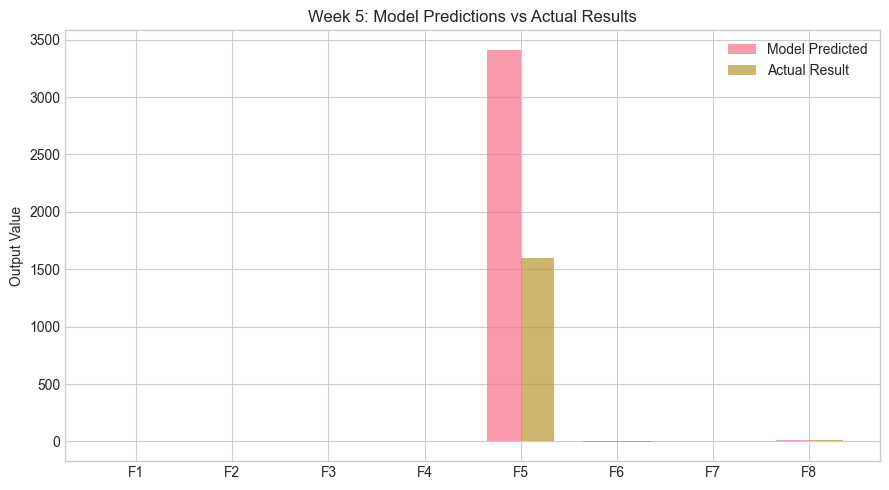

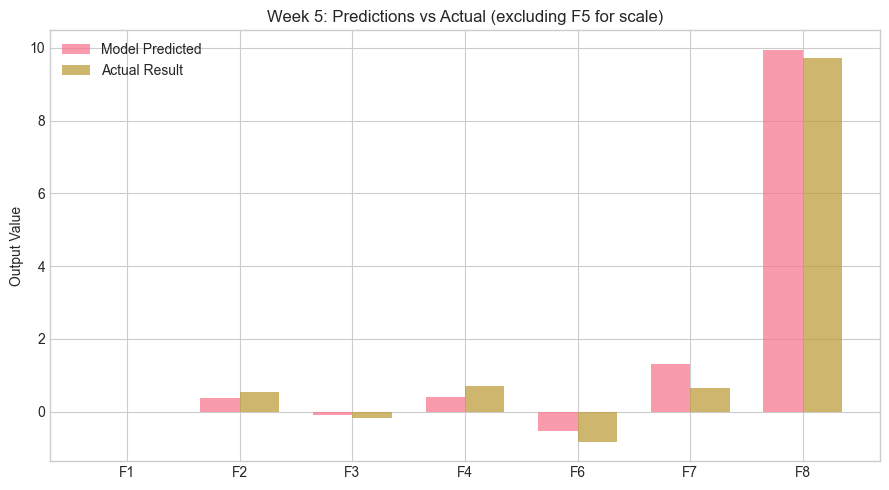

In [11]:
# Quick visual — predicted vs actual
fig, ax = plt.subplots(figsize=(9, 5))

fids = [f'F{i}' for i in range(1, 9)]
predicted = [results_rows[i]['Model Predicted'] for i in range(8)]
actual = [results_rows[i]['Actual Result'] for i in range(8)]

x_pos = np.arange(len(fids))
width = 0.35

ax.bar(x_pos - width/2, predicted, width, label='Model Predicted', alpha=0.7)
ax.bar(x_pos + width/2, actual, width, label='Actual Result', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(fids)
ax.set_ylabel('Output Value')
ax.set_title('Week 5: Model Predictions vs Actual Results')
ax.legend()
plt.tight_layout()
plt.show()

# F5 dominates the scale, so let's also show without it
fig, ax = plt.subplots(figsize=(9, 5))
fids_no5 = [f'F{i}' for i in range(1, 9) if i != 5]
pred_no5 = [results_rows[i]['Model Predicted'] for i in range(8) if i != 4]
actual_no5 = [results_rows[i]['Actual Result'] for i in range(8) if i != 4]

x_pos = np.arange(len(fids_no5))
ax.bar(x_pos - width/2, pred_no5, width, label='Model Predicted', alpha=0.7)
ax.bar(x_pos + width/2, actual_no5, width, label='Actual Result', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(fids_no5)
ax.set_ylabel('Output Value')
ax.set_title('Week 5: Predictions vs Actual (excluding F5 for scale)')
ax.legend()
plt.tight_layout()
plt.show()

### What surprised me

**F4 was the big win.** It jumped from -4.026 to 0.696. The model found a completely different part of the input space that none of our earlier queries had explored. This was a function where baseline data had been our best result for weeks, so it's satisfying to see the model actually beat it.

**F5 was disappointing.** It dropped from 3338.8 to 1600. The model pushed toward a boundary point that didn't pay off. The Week 4 sweet spot was near [0.15, 0.95, 0.98, 0.98] and the model moved x1 and x4 to the boundary, which clearly hurt.

**F8 edged up slightly** to 9.729 (from 9.69). Not dramatic, but the model is nudging in the right direction.

**Baseline still wins for F2, F3, F6, F7.** Our weekly queries haven't beaten the initial sample data for these functions yet. The model needs more data or a different strategy for these.

For Week 6, we're switching several functions from UCB (explore) to EI (exploit) based on these results. Functions where we found good regions should be exploited more carefully, while the ones still below baseline need continued exploration.

**Dimension importance shifted after Week 5.** For F5, x3 is now clearly the dominant dimension (importance 4.1) while x1 and x2 barely register. x4, which we assumed was a key driver, matters moderately (0.71) but much less than x3. For F2, x1 is more important than x2 — not what our earlier queries suggested.

---

### 11. Week 6 Results — Did the Strategy Change Pay Off?

Week 6 had two changes: kernel auto-selection (picking the best model shape per function) and per-function UCB/EI choice based on what W5 told us. Here's how it went.

In [ ]:
# To get the "pre-W6 predictions" we need to refit models on W1-W5 data only
# (W6 results are now on disk, so we can't just call fit_gp blindly)

from src.surrogate import FUNCTION_DIMENSIONS, _build_candidate_kernels
from sklearn.gaussian_process import GaussianProcessRegressor

def load_up_to_week(fid, max_week):
    dim = FUNCTION_DIMENSIONS[fid]
    x_cols = [f'x{i}' for i in range(1, dim + 1)]

    bl = pd.read_csv(PROJECT_ROOT / 'data' / 'baseline' / f'function_{fid}_baseline.csv')
    X_parts = [bl[x_cols].values]
    y_parts  = [bl['y'].values]

    for w in range(1, max_week + 1):
        path = PROJECT_ROOT / 'data' / 'weekly' / f'week_{w:02d}.csv'
        wk  = pd.read_csv(path)
        row = wk[wk['function_id'] == fid]
        if row.empty:
            continue
        row    = row.iloc[0]
        x_vals = row[x_cols].values.astype(float)
        if np.any(np.isnan(x_vals)):
            continue
        y_val = row['y'] if pd.notna(row['y']) else float(row.dropna().iloc[-1])
        X_parts.append(x_vals.reshape(1, -1))
        y_parts.append(np.array([y_val]))

    return np.vstack(X_parts), np.concatenate(y_parts)


def fit_gp_up_to(fid, max_week):
    X, y = load_up_to_week(fid, max_week)
    candidates = _build_candidate_kernels(X.shape[1])
    best_gp, best_score = None, -np.inf
    for kernel in candidates:
        gp = GaussianProcessRegressor(
            kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=42
        )
        try:
            gp.fit(X, y)
            if gp.log_marginal_likelihood_value_ > best_score:
                best_score = gp.log_marginal_likelihood_value_
                best_gp    = gp
        except Exception:
            continue
    return best_gp, X, y


# W6 query points (what was actually submitted)
w6_queries = {
    1: [0.612176, 0.202567],
    2: [0.962479, 0.999000],
    3: [0.999000, 0.999000, 0.417347],
    4: [0.422695, 0.413671, 0.268146, 0.434258],
    5: [0.999000, 0.999000, 0.999000, 0.999000],
    6: [0.499198, 0.365176, 0.874685, 0.764196, 0.001000],
    7: [0.001000, 0.001015, 0.998996, 0.272309, 0.350786, 0.685167],
    8: [0.001000, 0.001000, 0.001000, 0.001000, 0.999000, 0.001000, 0.001000, 0.999000],
}

# W6 actual results
w6_actuals = {
    1: -4.734625350973317e-60,
    2: -0.05789476101239359,
    3: -0.0665800662574871,
    4: -1.0695757471084906,
    5:  8585.271169822427,
    6: -0.46401267670670465,
    7:  1.1494376656088043,
    8:  9.5221494,
}

# Get model predictions at W6 query points using W1-W5 data only
w6_results_rows = []
for fid in range(1, 9):
    gp, X_hist, y_hist = fit_gp_up_to(fid, max_week=5)
    x_q   = np.array(w6_queries[fid]).reshape(1, -1)
    mu, _ = gp.predict(x_q, return_std=True)
    prev_best = y_hist.max()
    actual    = w6_actuals[fid]
    w6_results_rows.append({
        'Function':      fid,
        'Previous Best': prev_best,
        'Predicted':     round(float(mu[0]), 4),
        'Actual':        round(actual, 4),
        'New Best?':     'YES' if actual > prev_best else '',
    })

w6_df = pd.DataFrame(w6_results_rows)
print('Week 6 Results vs Model Predictions')
print('=' * 70)
print(w6_df.to_string(index=False))

In [ ]:
# F5 dominates the scale completely (8585 vs everything else near 0-1)
# Plot excluding F5 to see the others clearly, then show F5 separately

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fids_no5   = [r['Function'] for r in w6_results_rows if r['Function'] != 5]
pred_no5   = [r['Predicted'] for r in w6_results_rows if r['Function'] != 5]
actual_no5 = [r['Actual']    for r in w6_results_rows if r['Function'] != 5]
labels_no5 = [f'F{f}' for f in fids_no5]

x_pos  = np.arange(len(labels_no5))
width  = 0.35

ax = axes[0]
ax.bar(x_pos - width/2, pred_no5,   width, label='Predicted', alpha=0.7)
ax.bar(x_pos + width/2, actual_no5, width, label='Actual',    alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_no5)
ax.set_ylabel('Output Value')
ax.set_title('Week 6: Predictions vs Actual (F1–F4, F6–F8)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

# F5 on its own
ax = axes[1]
f5_row = next(r for r in w6_results_rows if r['Function'] == 5)
ax.bar(['Predicted', 'Actual'], [f5_row['Predicted'], f5_row['Actual']], alpha=0.7)
ax.set_title('Function 5 — the big story')
ax.set_ylabel('Output Value')

plt.tight_layout()
plt.show()

### What happened in Week 6

**F5 was the standout.** The model predicted roughly the same value as before (around 3400 area), but the actual result came back at 8585 — more than double. The all-upper-boundary point [0.999, 0.999, 0.999, 0.999] hit a region the model hadn't seen before and the function jumped massively. The model was right that the upper corner was good; it just didn't know how good.

**F6 beat the baseline for the first time.** The model-driven EI candidate landed at -0.464, improving on the baseline's -0.714. Not dramatic, but it's the first function where the surrogate actually found something better than the initial data.

**F4 fell back hard.** After last week's breakthrough at 0.696, this week returned -1.07. The EI candidate moved x3 down from 0.354 to 0.268, and that was enough to land somewhere much worse. F4 appears to have a narrow good region and the model overstepped it slightly.

**F2 went negative this week**, which was a surprise — the UCB candidate pushed into an area the model thought was promising but turned out to be poor.

For Week 7, F5 is now the clear leader but we're sitting at the hard boundary of the search space — the model can't propose anything beyond [0.999, 0.999, 0.999, 0.999]. The focus shifts to recovering F4 toward the W5 region and seeing if F6 momentum holds.

---

### 12. Week 7 Results — Confirming the F5 Corner

W7 was a deliberate experiment for F5. We knew [0.999, 0.999, 0.999, 0.999] = 8585 from W6. W7 pulled x3 to 0.001 to test whether x3 actually needs to be high. The answer came back clearly.

In [ ]:
# Pre-W7 predictions: refit on W1-W6 data only, then predict at W7 query points

w7_queries = {
    1: [0.614627, 0.533015],
    2: [0.745880, 0.999000],
    3: [0.001006, 0.001002, 0.645130],
    4: [0.393203, 0.401650, 0.396138, 0.437314],
    5: [0.999000, 0.999000, 0.001000, 0.999000],
    6: [0.525566, 0.338267, 0.583649, 0.726075, 0.001000],
    7: [0.001000, 0.999000, 0.001000, 0.250329, 0.413485, 0.749156],
    8: [0.121347, 0.122377, 0.205631, 0.001000, 0.999000, 0.489569, 0.250121, 0.391168],
}

w7_actuals = {
    1: -4.423286286293857e-7,
    2:  0.41225083199523127,
    3: -0.16242549366627032,
    4:  0.11145025459913471,
    5:  4399.055144422677,
    6: -0.3275224709883594,
    7:  0.12286957767436947,
    8:  9.9296698211046,
}

w7_results_rows = []
for fid in range(1, 9):
    gp, X_hist, y_hist = fit_gp_up_to(fid, max_week=6)
    x_q = np.array(w7_queries[fid]).reshape(1, -1)
    mu, _ = gp.predict(x_q, return_std=True)
    prev_best = y_hist.max()
    actual    = w7_actuals[fid]
    w7_results_rows.append({
        'Function':      fid,
        'Previous Best': prev_best,
        'Predicted':     round(float(mu[0]), 4),
        'Actual':        round(actual, 4),
        'New Best?':     'YES' if actual > prev_best else '',
    })

w7_df = pd.DataFrame(w7_results_rows)
print('Week 7 Results vs Model Predictions')
print('=' * 70)
print(w7_df.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fids_no5   = [r['Function'] for r in w7_results_rows if r['Function'] != 5]
pred_no5   = [r['Predicted'] for r in w7_results_rows if r['Function'] != 5]
actual_no5 = [r['Actual']    for r in w7_results_rows if r['Function'] != 5]

x_pos = np.arange(len(fids_no5))
width = 0.35

ax = axes[0]
ax.bar(x_pos - width/2, pred_no5,   width, label='Predicted', alpha=0.7)
ax.bar(x_pos + width/2, actual_no5, width, label='Actual',    alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'F{f}' for f in fids_no5])
ax.set_ylabel('Output Value')
ax.set_title('Week 7: Predictions vs Actual (F1–F4, F6–F8)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
f5_row = next(r for r in w7_results_rows if r['Function'] == 5)
ax.bar(['W6 best\n[0.999,0.999,0.999,0.999]', 'W7 probe\n[0.999,0.999,0.001,0.999]'],
       [8585.3, f5_row['Actual']], alpha=0.7, color=['steelblue', 'orange'])
ax.set_title('F5: x3=0.999 vs x3=0.001')
ax.set_ylabel('Output Value')

plt.tight_layout()
plt.show()

### What happened in Week 7

**F5 answered the question.** Pulling x3 from 0.999 to 0.001 dropped the output from 8585 to 4399 — a 49% fall. That settles it: x3 needs to be at the upper boundary. The W8 query probes x4 the same way: [0.999, 0.999, 0.999, 0.001]. If x4 doesn't matter, the output should stay near 8585.

**F8 hit a new best at 9.930.** The EI candidate had x6≈0.49, closer to the W5 winner pattern. The model is converging on the right region here.

**F6 keeps improving.** -0.328 this week, up from -0.464. It has beaten the baseline consistently for two weeks now.

**F7 fell sharply to 0.123.** The EI candidate moved into a poor region. Switching back to UCB for W8 — this function needs to search more broadly rather than exploit a region that clearly isn't working.

**The surrogate got stuck on F4.** When I ran the model for W8 queries, both UCB and EI returned points within 0.003 of the W7 query. That's essentially the same point again. I overrode it manually with [0.425, 0.418, 0.360, 0.435], nudging x3 back toward the W5 winner value of 0.354. The model needs a few more data points around the good region before it can reliably guide F4 on its own.

### Week 8 Query Strategy

Here's how the W8 acquisition decisions were made, including the duplicate check that forced manual overrides.

## Week 8 Results

W8 gave us the final answer on F5 — and confirmed F4 is still recoverable.

In [ ]:
# Refit models on W1-W7 data, predict at W8 query points
# (fit_gp_up_to is defined earlier in this notebook)

w8_actuals = {
    1: (0.917043, 0.315650),
    2: (0.001000, 0.998999),
    3: (0.999000, 0.999000, 0.515199),
    4: (0.425000, 0.418000, 0.360000, 0.435000),
    5: (0.999000, 0.999000, 0.999000, 0.001000),
    6: (0.463859, 0.290142, 0.580121, 0.620495, 0.001000),
    7: (0.001000, 0.336419, 0.998998, 0.253121, 0.335176, 0.629453),
    8: (0.181608, 0.115945, 0.090390, 0.002542, 0.999000, 0.346748, 0.252121, 0.001000),
}
w8_outputs = {1: 1.41e-126, 2: 0.1766, 3: -0.0664, 4: 0.5491, 5: 4399.1, 6: -0.4576, 7: 1.1398, 8: 9.8745}

rows = []
for fid in range(1, 9):
    gp, X, y = fit_gp_up_to(fid, max_week=7)
    if gp is None:
        rows.append({"Function": f"F{fid}", "Predicted": None, "Actual": w8_outputs[fid], "Sigma": None})
        continue
    x_query = np.array(w8_actuals[fid]).reshape(1, -1)
    mu, sigma = gp.predict(x_query, return_std=True)
    rows.append({"Function": f"F{fid}", "Predicted": round(float(mu[0]), 4), "Actual": w8_outputs[fid], "Sigma": round(float(sigma[0]), 4)})

df_w8 = pd.DataFrame(rows)
print(df_w8.to_string(index=False))


In [ ]:
# Bar chart: predicted vs actual for W8 (excluding F1 and F5 due to scale)
plot_fids = [2, 3, 4, 6, 7, 8]
df_plot = df_w8[df_w8["Function"].isin([f"F{i}" for i in plot_fids])]

x = np.arange(len(df_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, df_plot["Predicted"], width, label="Predicted", color="steelblue", alpha=0.8)
ax.bar(x + width/2, df_plot["Actual"], width, label="Actual", color="coral", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Function"])
ax.set_title("Week 8: Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()


### What happened in Week 8

**F5 answered the x4 question.** Pulling x4 to 0.001 returned 4399 — the same drop as the W7 x3 probe. So the function needs all four inputs near 0.999 to reach the 8585 peak. The corner is the optimum.

**F4 is recovering.** The manual point near x3=0.354 returned 0.549, much better than W7's 0.111. The surrogate alone keeps drifting back toward W7, so manual guidance is still needed here.

**F6 dropped to -0.458.** The EI candidate shifted x4 lower than W7's best point and it paid the price. Switching back to UCB for W9.

**F8 slipped slightly to 9.874.** The EI candidate pushed x8 toward 0.001, which seems to hurt. Still above baseline, but the model needs to relearn that pattern.

## Week 9 Results

W9 delivered two new bests and closed the book on F5.

In [ ]:
# Refit models on W1-W8 data, predict at W9 query points
w9_actuals = {
    1: (0.222957, 0.787186),
    2: (0.679647, 0.999000),
    3: (0.294426, 0.199019, 0.001002),
    4: (0.440000, 0.430000, 0.354000, 0.410000),
    5: (0.001000, 0.999000, 0.999000, 0.999000),
    6: (0.512173, 0.437992, 0.509197, 0.946987, 0.001000),
    7: (0.001000, 0.317072, 0.001002, 0.273218, 0.385810, 0.764440),
    8: (0.084783, 0.205288, 0.130521, 0.189672, 0.999000, 0.518717, 0.237023, 0.590873),
}
w9_outputs = {1: 1.93e-122, 2: 0.4802, 3: -0.1408, 4: 0.3932, 5: 4399.1, 6: -0.6349, 7: 1.5363, 8: 9.9720}

rows = []
for fid in range(1, 9):
    gp, X, y = fit_gp_up_to(fid, max_week=8)
    if gp is None:
        rows.append({"Function": f"F{fid}", "Predicted": None, "Actual": w9_outputs[fid], "Sigma": None})
        continue
    x_query = np.array(w9_actuals[fid]).reshape(1, -1)
    mu, sigma = gp.predict(x_query, return_std=True)
    rows.append({"Function": f"F{fid}", "Predicted": round(float(mu[0]), 4), "Actual": w9_outputs[fid], "Sigma": round(float(sigma[0]), 4)})

df_w9 = pd.DataFrame(rows)
print(df_w9.to_string(index=False))


In [ ]:
# Bar chart: predicted vs actual for W9 (excluding F1 and F5 due to scale)
plot_fids = [2, 3, 4, 6, 7, 8]
df_plot = df_w9[df_w9["Function"].isin([f"F{i}" for i in plot_fids])]

x = np.arange(len(df_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, df_plot["Predicted"], width, label="Predicted", color="steelblue", alpha=0.8)
ax.bar(x + width/2, df_plot["Actual"], width, label="Actual", color="coral", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Function"])
ax.set_title("Week 9: Predicted vs Actual")
ax.legend()
plt.tight_layout()
plt.show()


### What happened in Week 9

**F7 beat the baseline.** UCB found a point returning 1.536, the first time F7 has beaten the baseline of 1.365. This was a genuine surprise — the function had been volatile for weeks.

**F8 improved again.** EI returned 9.972, another new high. The model is reliably finding better points here.

**F5 corner map is complete.** x1=0.001 dropped the output to 4399 — the same result as the x3 and x4 probes in W7 and W8. All four dimensions must be at 0.999 to reach the 8585 peak. There is nothing more to probe; the full upper corner is the optimum.

**F6 went badly.** UCB sent it to -0.634, the worst F6 result across all weeks. Switching back to EI for W10.

**F4 is drifting.** 0.393 this week, down from 0.549 in W8. The region around x3=0.354 exists but it is narrow and the model keeps sliding around it.

## Week 10 Results

W10 had one big win: F2 finally beat its baseline.

In [ ]:
# Refit models on W1-W9 data, predict at W10 query points
w10_actuals = {
    1: (0.998999, 0.466806),
    2: (0.716599, 0.999000),
    3: (0.999000, 0.625316, 0.999000),
    4: (0.399267, 0.415677, 0.398409, 0.439090),
    5: (0.999000, 0.001000, 0.999000, 0.999000),
    6: (0.547409, 0.368589, 0.621112, 0.692216, 0.001000),
    7: (0.001000, 0.314253, 0.999000, 0.281114, 0.412321, 0.737546),
    8: (0.184005, 0.151543, 0.135914, 0.102596, 0.999000, 0.548812, 0.199242, 0.902187),
}
w10_outputs = {1: -3.57e-114, 2: 0.6937, 3: -0.4348, 4: 0.2952, 5: 4399.1, 6: -0.3804, 7: 1.0221, 8: 9.9522}

rows = []
for fid in range(1, 9):
    gp, X, y = fit_gp_up_to(fid, max_week=9)
    if gp is None:
        rows.append({'Function': f'F{fid}', 'Predicted': None, 'Actual': w10_outputs[fid], 'Sigma': None})
        continue
    x_query = np.array(w10_actuals[fid]).reshape(1, -1)
    mu, sigma = gp.predict(x_query, return_std=True)
    rows.append({'Function': f'F{fid}', 'Predicted': round(float(mu[0]), 4), 'Actual': w10_outputs[fid], 'Sigma': round(float(sigma[0]), 4)})

df_w10 = pd.DataFrame(rows)
print(df_w10.to_string(index=False))

In [ ]:
# Bar chart: predicted vs actual for W10 (excluding F1 and F5 due to scale)
plot_fids = [2, 3, 4, 6, 7, 8]
df_plot = df_w10[df_w10['Function'].isin([f'F{i}' for i in plot_fids])]

x = np.arange(len(df_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, df_plot['Predicted'], width, label='Predicted', color='steelblue', alpha=0.8)
ax.bar(x + width/2, df_plot['Actual'], width, label='Actual', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Function'])
ax.set_title('Week 10: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

### What happened in Week 10

**F2 beat the baseline.** The query at [0.716, 0.999] returned 0.694, above the baseline best of 0.611. First time F2 has beaten its baseline across all ten weeks. The x2=0.999 pattern in W9 and W10 both giving strong results suggests x2 matters.

**F5 corner map complete.** Pulling x2 to 0.001 returned 4399 — same as every other single-dimension probe. All four dimensions confirmed: the only way to reach 8585 is with all four inputs at 0.999.

**F7 dropped.** EI returned 1.022, down from the W9 best of 1.536. The model overshot. Back to UCB for W11.

**F3 worst ever.** UCB explored a corner that returned -0.435. Baseline -0.035 still unchallenged.

**F4 stuck.** 0.295 this week — surrogate keeps proposing near-duplicate points in the same narrow neighbourhood. W11 uses a manual override to [0.430, 0.390, 0.354, 0.460] to break out.

## Week 11 Results

F7 hit a new high and F5 gave us useful gradient information about the peak.

In [ ]:
# Refit models on W1-W10 data, predict at W11 query points
w11_actuals = {
    1: (0.999000, 0.999000),
    2: (0.722019, 0.653519),
    3: (0.001000, 0.999000, 0.801989),
    4: (0.430000, 0.390000, 0.354000, 0.460000),
    5: (0.980000, 0.999000, 0.999000, 0.999000),
    6: (0.538101, 0.258663, 0.604872, 0.744493, 0.001000),
    7: (0.001000, 0.252646, 0.048338, 0.205417, 0.293725, 0.800670),
    8: (0.001000, 0.266681, 0.150685, 0.077808, 0.999000, 0.642006, 0.223255, 0.999000),
}
w11_outputs = {1: 1.48e-191, 2: 0.4682, 3: -0.1013, 4: -0.2593, 5: 8233.7, 6: -0.4250, 7: 1.6845, 8: 9.9033}

rows = []
for fid in range(1, 9):
    gp, X, y = fit_gp_up_to(fid, max_week=10)
    if gp is None:
        rows.append({'Function': f'F{fid}', 'Predicted': None, 'Actual': w11_outputs[fid], 'Sigma': None})
        continue
    x_query = np.array(w11_actuals[fid]).reshape(1, -1)
    mu, sigma = gp.predict(x_query, return_std=True)
    rows.append({'Function': f'F{fid}', 'Predicted': round(float(mu[0]), 4), 'Actual': w11_outputs[fid], 'Sigma': round(float(sigma[0]), 4)})

df_w11 = pd.DataFrame(rows)
print(df_w11.to_string(index=False))

In [ ]:
# Bar chart: predicted vs actual for W11 (excluding F1 and F5 due to scale)
plot_fids = [2, 3, 4, 6, 7, 8]
df_plot = df_w11[df_w11['Function'].isin([f'F{i}' for i in plot_fids])]

x = np.arange(len(df_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, df_plot['Predicted'], width, label='Predicted', color='steelblue', alpha=0.8)
ax.bar(x + width/2, df_plot['Actual'], width, label='Actual', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Function'])
ax.set_title('Week 11: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

### What happened in Week 11

**F7 new best.** UCB returned 1.685, beating the previous best of 1.536 from W9. The model keeps finding better points for F7 when given room to explore.

**F5 gradient confirmed.** x1=0.980 returned 8233, down from 8585 at x1=0.999. That is only a 4% drop for a shift of 0.019 — the peak is broad, not a spike. W12 probes x2 to see if the gradient is similar in that dimension.

**F2 x2 requirement confirmed.** Dropping x2 from 0.999 to 0.654 pushed the output from 0.694 down to 0.468. The model proposed x2=0.001 for W12 despite this evidence, so W12 uses a manual override.

**F4 still struggling.** Moving to [0.430, 0.390, 0.354, 0.460] went negative — the function is sensitive to all four dimensions together, not just x3.

## Week 12 Results

F7 hit another new best and F5 confirmed the peak gradient is symmetric.

In [ ]:
# Refit models on W1-W11 data, predict at W12 query points
w12_actuals = {
    1: (0.544040, 0.994256),
    2: (0.780000, 0.999000),
    3: (0.999000, 0.358015, 0.079070),
    4: (0.395838, 0.429000, 0.396088, 0.432345),
    5: (0.999000, 0.980000, 0.999000, 0.999000),
    6: (0.508158, 0.417250, 0.574426, 0.695961, 0.001000),
    7: (0.001000, 0.247899, 0.001000, 0.209422, 0.356599, 0.712583),
    8: (0.103904, 0.029343, 0.138175, 0.227506, 0.999000, 0.538030, 0.246761, 0.681034),
}
w12_outputs = {1: 1.16e-98, 2: 0.1281, 3: -0.0375, 4: 0.3810, 5: 8233.7, 6: -0.3529, 7: 1.7562, 8: 9.9529}

rows = []
for fid in range(1, 9):
    gp, X, y = fit_gp_up_to(fid, max_week=11)
    if gp is None:
        rows.append({'Function': f'F{fid}', 'Predicted': None, 'Actual': w12_outputs[fid], 'Sigma': None})
        continue
    x_query = np.array(w12_actuals[fid]).reshape(1, -1)
    mu, sigma = gp.predict(x_query, return_std=True)
    rows.append({'Function': f'F{fid}', 'Predicted': round(float(mu[0]), 4), 'Actual': w12_outputs[fid], 'Sigma': round(float(sigma[0]), 4)})

df_w12 = pd.DataFrame(rows)
print(df_w12.to_string(index=False))

In [ ]:
# Bar chart: predicted vs actual for W12 (excluding F1 and F5 due to scale)
plot_fids = [2, 3, 4, 6, 7, 8]
df_plot = df_w12[df_w12['Function'].isin([f'F{i}' for i in plot_fids])]
x = np.arange(len(df_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, df_plot['Predicted'], width, label='Predicted', color='steelblue', alpha=0.8)
ax.bar(x + width/2, df_plot['Actual'], width, label='Actual', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Function'])
ax.set_title('Week 12: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

### What happened in Week 12

**F7 new best again.** EI returned 1.756, up from 1.685 in W11 and 1.536 in W9. F7 has improved in every exploitation round and is now well clear of the baseline of 1.365.

**F5 gradient confirmed symmetric.** Dropping x2 to 0.980 gave 8233, identical to the W11 result when x1 was dropped to 0.980. The peak falls at roughly the same rate in both dimensions.

**F3 nearest to baseline.** The EI proposal returned -0.038, within 0.003 of the baseline best of -0.035. This is the closest any weekly query has come for F3.

**F2 confirmed sweet spot.** Pushing x1 to 0.780 dropped the output to 0.128. The W10 point at x1=0.716 remains the best, confirming the x1 sweet spot is narrow.

**F6 recovering.** EI returned -0.353, the best result since W7's -0.328.

## Week 13 Results (Final Round)

This is the last week of queries. I fitted the surrogate on W1-W12 data and predicted at the W13 query points to see how well the model tracked the actual outputs.

In [ ]:
# Refit models on W1-W12 data, predict at W13 query points
w13_actuals = {
    1: (0.491051, 0.581838),
    2: (0.700103, 0.999000),
    3: (0.999000, 0.999000, 0.059438),
    4: (0.460000, 0.380000, 0.354000, 0.400000),
    5: (0.999000, 0.999000, 0.985000, 0.999000),
    6: (0.500496, 0.393174, 0.509448, 0.719375, 0.001000),
    7: (0.001000, 0.189626, 0.001000, 0.202738, 0.396653, 0.811924),
    8: (0.147274, 0.170121, 0.161784, 0.198811, 0.999000, 0.465160, 0.166197, 0.497094),
}
w13_outputs = {
    1: -9.274e-16,
    2: 0.6653,
    3: -0.0692,
    4: -0.4478,
    5: 8323.6,
    6: -0.4222,
    7: 1.3909,
    8: 9.9653,
}

import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
from src.surrogate import fit_gp, load_all_data
from src.functions_map import FUNCTION_DIMENSIONS

records = []
for fid in range(1, 9):
    dims = FUNCTION_DIMENSIONS[fid]
    X, y = load_all_data(fid, up_to_week=12)
    gp, _ = fit_gp(X, y)
    x_query = np.array(w13_actuals[fid]).reshape(1, -1)
    pred_mean, pred_std = gp.predict(x_query, return_std=True)
    records.append({
        'Function': f'F{fid}',
        'Predicted': round(float(pred_mean[0]), 4),
        'Actual': w13_outputs[fid],
        'Error': round(abs(float(pred_mean[0]) - w13_outputs[fid]), 4),
    })

df_w13 = pd.DataFrame(records)
print(df_w13.to_string(index=False))

In [ ]:
# Bar chart: predicted vs actual for W13 (excluding F1 and F5 due to scale)
import matplotlib.pyplot as plt

plot_fids = [2, 3, 4, 6, 7, 8]
df_plot = df_w13[df_w13['Function'].isin([f'F{i}' for i in plot_fids])].copy()

x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - width/2 for i in x], df_plot['Predicted'], width, label='Predicted', color='steelblue')
ax.bar([i + width/2 for i in x], df_plot['Actual'], width, label='Actual', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['Function'].tolist())
ax.set_title('W13 predicted vs actual (F2-F8, excluding F1 and F5)')
ax.set_ylabel('Output value')
ax.legend()
plt.tight_layout()
plt.show()

### What happened in Week 13 (Final)

**F5 surprise.** The x3=0.985 probe returned 8323.6, which is higher than both W11 and W12's x1/x2=0.980 probes (both gave 8233). That suggests x3 has a slightly shallower gradient near the peak compared to x1 and x2. Small difference but interesting.

**F2 held up well.** UCB near x1=0.700, x2=0.999 gave 0.665 — very close to the W10 best of 0.694. The region is reliable.

**F8 consistent.** EI in the x5=0.999 neighbourhood gave 9.965, almost matching the W9 all-time best of 9.972.

**F7 overshot.** EI returned 1.391, dropping from the W12 best of 1.756. The model found a nearby point that turned out to be worse. This is the risk of EI on the last query — no chance to course-correct.

**Final score: 7 out of 8 beat the baseline.** F3 is the only function that never surpassed its baseline best of -0.035, though W12 came within 0.003 of matching it.